# Speed dating

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, KNNImputer

In [53]:
df = pd.read_csv('./data/speeddating.csv')
df.head(3)

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,b'',1.0,b'female',21.0,27.0,6.0,b'[4-6]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,6.0,b'[6-8]',b'[5-6]',0.0,b'1',b'0',b'0'
1,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',...,b'[0-3]',b'[3-5]',7.0,5.0,b'[6-8]',b'[5-6]',1.0,b'1',b'0',b'0'
2,b'',1.0,b'female',21.0,22.0,1.0,b'[0-1]',b'Asian/Pacific Islander/Asian-American',b'Asian/Pacific Islander/Asian-American',b'1',...,b'[0-3]',b'[3-5]',7.0,NaN,b'[6-8]',b'[0-4]',1.0,b'1',b'1',b'1'


In [54]:
columns_to_drop = ['has_null', 'wave', 'd_d_age', 'd_importance_same_race', 'd_importance_same_religion',
                   'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence',
                   'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests',
                   'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 
                   'd_shared_interests_o', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important',
                   'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
                   'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important',
                   'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition',
                   'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner', 
                   'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner',
                   'd_shared_interests_partner', 'd_sports', 'd_tvsports', 'd_exercise', 'd_dining', 'd_museums',
                   'd_art', 'd_hiking', 'd_gaming', 'd_clubbing', 'd_reading', 'd_tv', 'd_theater', 'd_movies',
                   'd_concerts', 'd_music', 'd_shopping', 'd_yoga', 'd_interests_correlate',
                   'd_expected_happy_with_sd_people', 'd_expected_num_interested_in_me', 'd_expected_num_matches',
                   'd_like', 'd_guess_prob_liked', 'like', 'guess_prob_liked', 'decision', 'decision_o']
print(len(columns_to_drop))

df = df.drop(columns=columns_to_drop)
df.head(3)

73


,gender,age,age_o,d_age,race,race_o,samerace,importance_same_race,importance_same_religion,field,...,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,met,match
0,b'female',21.0,27.0,6.0,b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',2.0,4.0,b'Law',...,10.0,9.0,8.0,1.0,0.14,3.0,2.0,4.0,0.0,b'0'
1,b'female',21.0,22.0,1.0,b'Asian/Pacific Islander/Asian-American',b'European/Caucasian-American',b'0',2.0,4.0,b'Law',...,10.0,9.0,8.0,1.0,0.54,3.0,2.0,4.0,1.0,b'0'
2,b'female',21.0,22.0,1.0,b'Asian/Pacific Islander/Asian-American',b'Asian/Pacific Islander/Asian-American',b'1',2.0,4.0,b'Law',...,10.0,9.0,8.0,1.0,0.16,3.0,2.0,4.0,1.0,b'1'


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         8378 non-null   str    
 1   age                            8283 non-null   float64
 2   age_o                          8274 non-null   float64
 3   d_age                          8378 non-null   float64
 4   race                           8378 non-null   str    
 5   race_o                         8378 non-null   str    
 6   samerace                       8378 non-null   str    
 7   importance_same_race           8299 non-null   float64
 8   importance_same_religion       8299 non-null   float64
 9   field                          8378 non-null   str    
 10  pref_o_attractive              8289 non-null   float64
 11  pref_o_sincere                 8289 non-null   float64
 12  pref_o_intelligence            8289 non-null   float64
 13 

In [56]:
print("liczba duplikatów:")
print(df.duplicated().sum())
df[df.duplicated(keep=False)]

liczba duplikatów:


10


,gender,age,age_o,d_age,race,race_o,samerace,importance_same_race,importance_same_religion,field,...,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,met,match
910,b'male',29.0,NaN,29.0,b'Latino/Hispanic American',b'?',b'0',1.0,1.0,b'Business & International Affairs',...,4.0,6.0,4.0,2.0,NaN,5.0,3.0,3.0,NaN,b'0'
911,b'male',29.0,NaN,29.0,b'Latino/Hispanic American',b'?',b'0',1.0,1.0,b'Business & International Affairs',...,4.0,6.0,4.0,2.0,NaN,5.0,3.0,3.0,NaN,b'0'
920,b'male',22.0,NaN,22.0,b'Other',b'?',b'0',1.0,1.0,b'Law',...,9.0,9.0,2.0,1.0,NaN,5.0,1.0,3.0,NaN,b'0'
921,b'male',22.0,NaN,22.0,b'Other',b'?',b'0',1.0,1.0,b'Law',...,9.0,9.0,2.0,1.0,NaN,5.0,1.0,3.0,NaN,b'0'
930,b'male',27.0,NaN,27.0,b'Black/African American',b'?',b'0',1.0,1.0,b'MFA Creative Writing',...,7.0,7.0,7.0,1.0,NaN,5.0,2.0,NaN,0.0,b'0'
931,b'male',27.0,NaN,27.0,b'Black/African American',b'?',b'0',1.0,1.0,b'MFA Creative Writing',...,7.0,7.0,7.0,1.0,NaN,5.0,2.0,NaN,0.0,b'0'
940,b'male',28.0,NaN,28.0,b'European/Caucasian-American',b'?',b'0',2.0,2.0,b'MBA',...,6.0,7.0,2.0,1.0,NaN,3.0,0.0,1.0,0.0,b'0'
941,b'male',28.0,NaN,28.0,b'European/Caucasian-American',b'?',b'0',2.0,2.0,b'MBA',...,6.0,7.0,2.0,1.0,NaN,3.0,0.0,1.0,0.0,b'0'
970,b'male',22.0,NaN,22.0,b'European/Caucasian-American',b'?',b'0',8.0,1.0,b'Engineering',...,6.0,8.0,8.0,4.0,NaN,7.0,9.0,1.0,0.0,b'0'
971,b'male',22.0,NaN,22.0,b'European/Caucasian-American',b'?',b'0',8.0,1.0,b'Engineering',...,6.0,8.0,8.0,4.0,NaN,7.0,9.0,1.0,0.0,b'0'


In [57]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
Index: 8368 entries, 0 to 8377
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         8368 non-null   str    
 1   age                            8273 non-null   float64
 2   age_o                          8274 non-null   float64
 3   d_age                          8368 non-null   float64
 4   race                           8368 non-null   str    
 5   race_o                         8368 non-null   str    
 6   samerace                       8368 non-null   str    
 7   importance_same_race           8289 non-null   float64
 8   importance_same_religion       8289 non-null   float64
 9   field                          8368 non-null   str    
 10  pref_o_attractive              8289 non-null   float64
 11  pref_o_sincere                 8289 non-null   float64
 12  pref_o_intelligence            8289 non-null   float64
 13  pref

In [58]:
df = df.drop(columns=['expected_num_interested_in_me'])

In [59]:
for col in df.select_dtypes(include='str').columns:
    df[col] = df[col].str.replace("b'", "").str.replace("'", "")
df.head(3)

,gender,age,age_o,d_age,race,race_o,samerace,importance_same_race,importance_same_religion,field,...,movies,concerts,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_matches,met,match
0,female,21.0,27.0,6.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.14,3.0,4.0,0.0,0
1,female,21.0,22.0,1.0,Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.54,3.0,4.0,1.0,0
2,female,21.0,22.0,1.0,Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,2.0,4.0,Law,...,10.0,10.0,9.0,8.0,1.0,0.16,3.0,4.0,1.0,1



## Rozkład klasy

Text(0.5, 1.0, "Rozkład match'a")

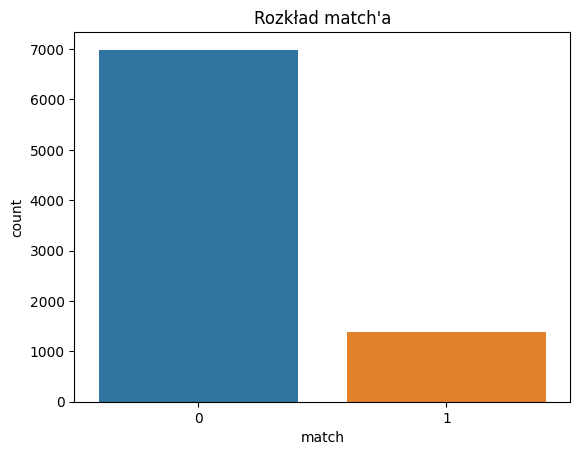

In [60]:
sns.countplot(df, x=df.match, hue='match')
plt.title('Rozkład match\'a')

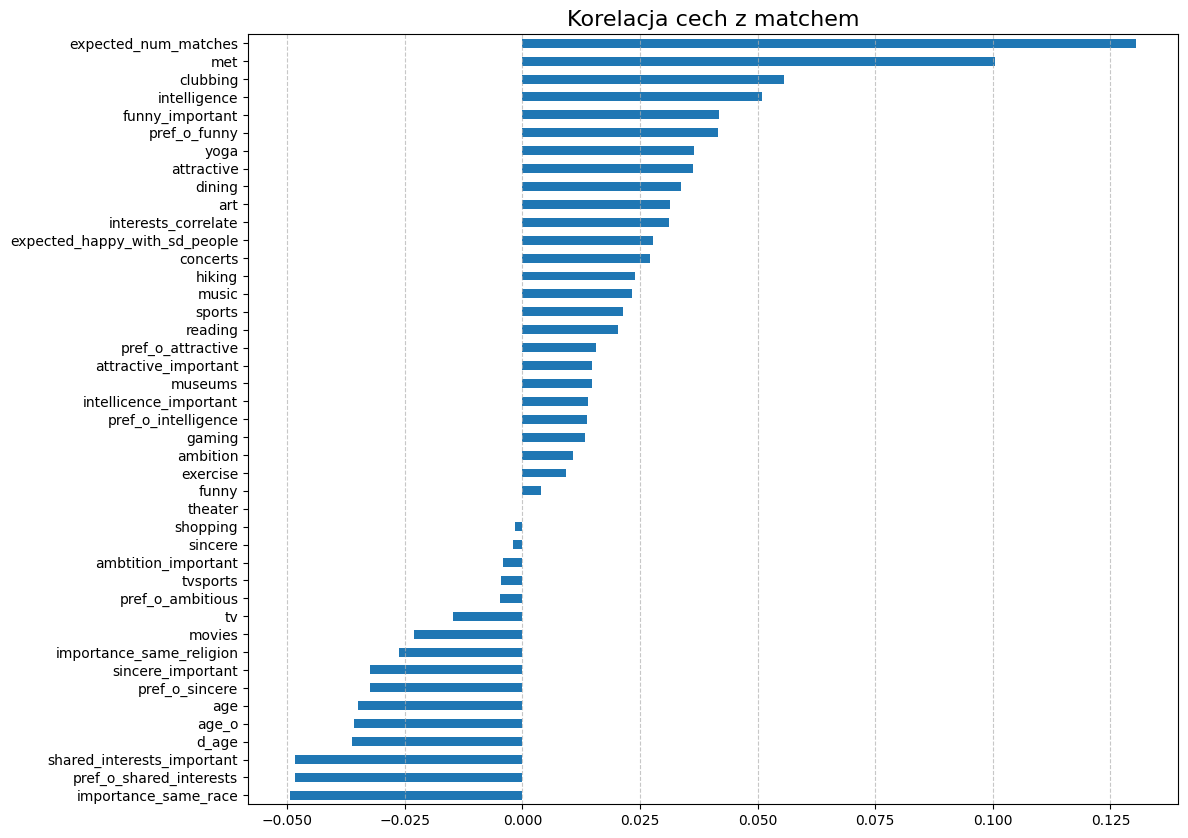

In [61]:
df['match'] = df['match'].astype('int64')

numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

correlations = corr_matrix['match'].drop('match').sort_values()

plt.figure(figsize=(12, 10))

correlations.plot(kind='barh')

plt.title('Korelacja cech z matchem', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### tworzenie ID

In [66]:
individual_features = ['gender', 'age', 'race', 'importance_same_race', 'importance_same_religion', 'field']

df['id'] = df.groupby(individual_features, sort=False).ngroup()

df.id

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
        ...  
8373    536.0
8374    536.0
8375    536.0
8376    536.0
8377    536.0
Name: id, Length: 8368, dtype: float64

## Rozkład cech

In [ ]:
print(df.nunique().sort_values(ascending=False).to_string())

field                            260
interests_correlate              155
attractive_important              94
pref_o_attractive                 94
pref_o_shared_interests           85
shared_interests_important        85
ambtition_important               82
pref_o_ambitious                  82
pref_o_sincere                    78
sincere_important                 78
pref_o_funny                      71
funny_important                   71
intellicence_important            65
pref_o_intelligence               65
d_age                             35
age_o                             24
age                               24
expected_num_matches              17
gaming                            12
reading                           11
clubbing                          11
hiking                            11
importance_same_race              11
concerts                          11
theater                           11
art                               11
museums                           11
y

In [ ]:
df['field'].unique().tolist()

['Law',
 'law',
 'Economics',
 'Masters in Public Administration',
 'Masters of Social Work&Education',
 'Finance',
 'Business',
 'political science',
 'money',
 'Operations Research',
 'TC [Health Ed]',
 'Psychology',
 'social work',
 'Social Work',
 'Speech Language Pathology',
 'Speech Languahe Pathology',
 'Educational Psychology',
 'Applied Maths/Econs',
 'Mathematics',
 'Statistics',
 'Organizational Psychology',
 'Mechanical Engineering',
 'Finanace',
 'Finance&Economics',
 'Undergrad - GS',
 'Mathematical Finance',
 'Medicine',
 'MBA',
 'LAW',
 '?',
 'psychology',
 'German Literature',
 'Business & International Affairs',
 'MFA Creative Writing',
 'Engineering',
 'Electrical Engineering',
 'Classics',
 'Operations Research [SEAS]',
 'chemistry',
 'Journalism',
 'Elementary/Childhood Education [MA]',
 'microbiology',
 'Masters of Social Work',
 'Communications',
 'Marketing',
 'Chemistry',
 'International Educational Development',
 'Education Administration',
 'Business [MBA]',


In [ ]:
df = df.drop(columns=['field'])

In [ ]:
print(df['met'].unique().tolist())
print(df['met'].nunique())
print(df['met'].value_counts())

[0.0, 1.0, nan, 3.0, 5.0, 7.0, 8.0, 6.0]
7
met
0.0    7636
1.0     351
7.0       3
5.0       2
3.0       1
8.0       1
6.0       1
Name: count, dtype: int64


In [ ]:
df['met'] = np.where(df['met'] >= 1, 1, 0)

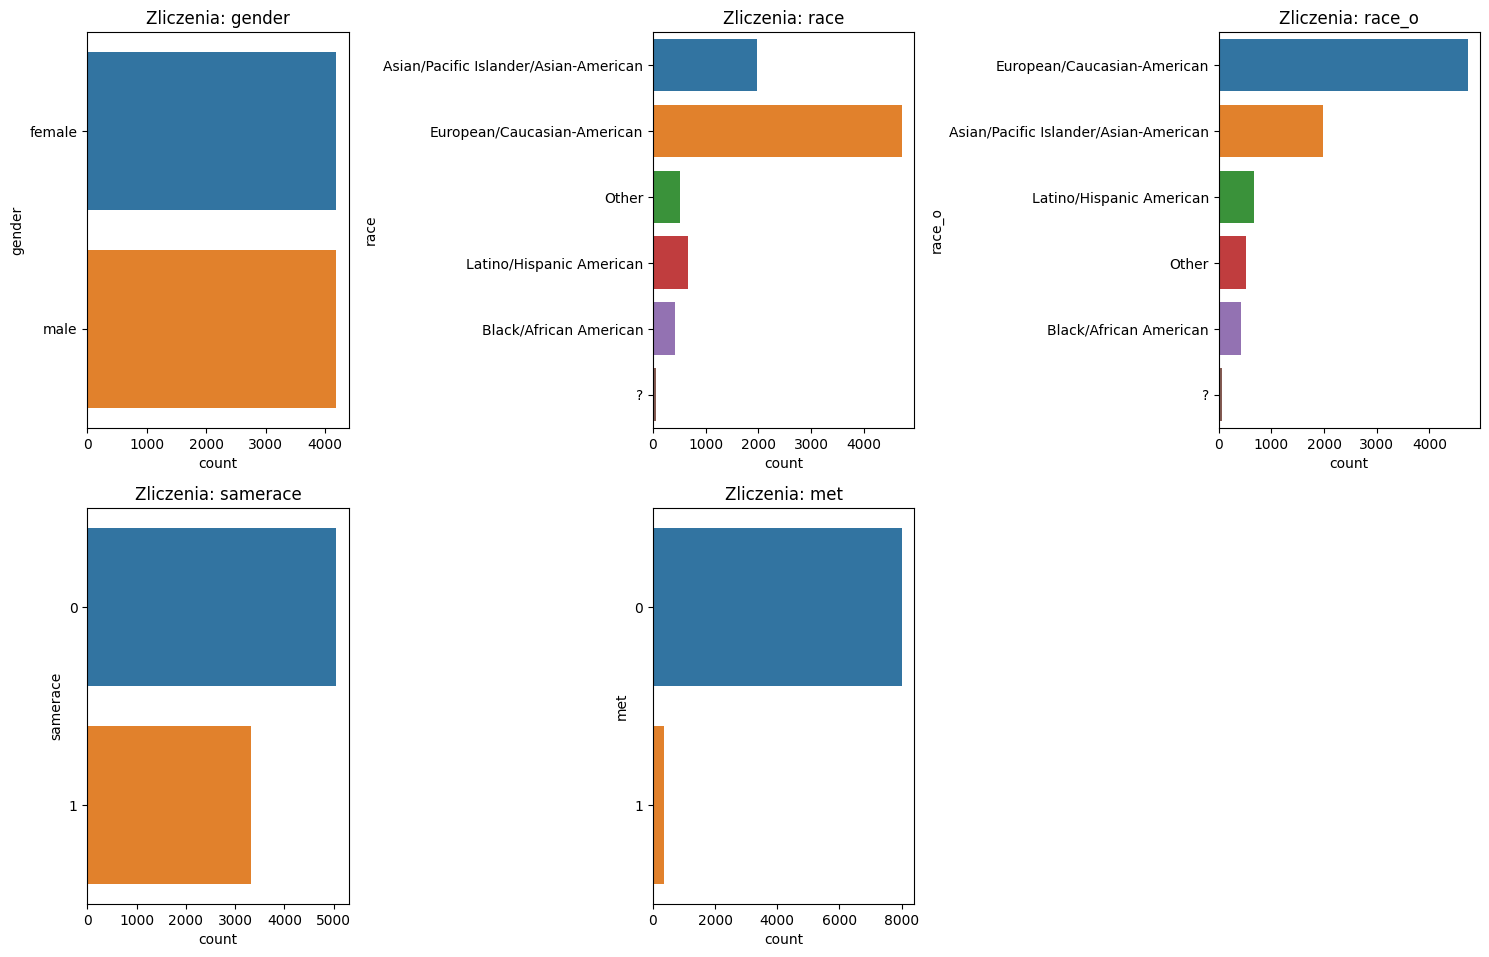

In [ ]:
categorical_cols = ['gender', 'race', 'race_o', 'samerace', 'met']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, y=col, ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Zliczenia: {col}')

    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

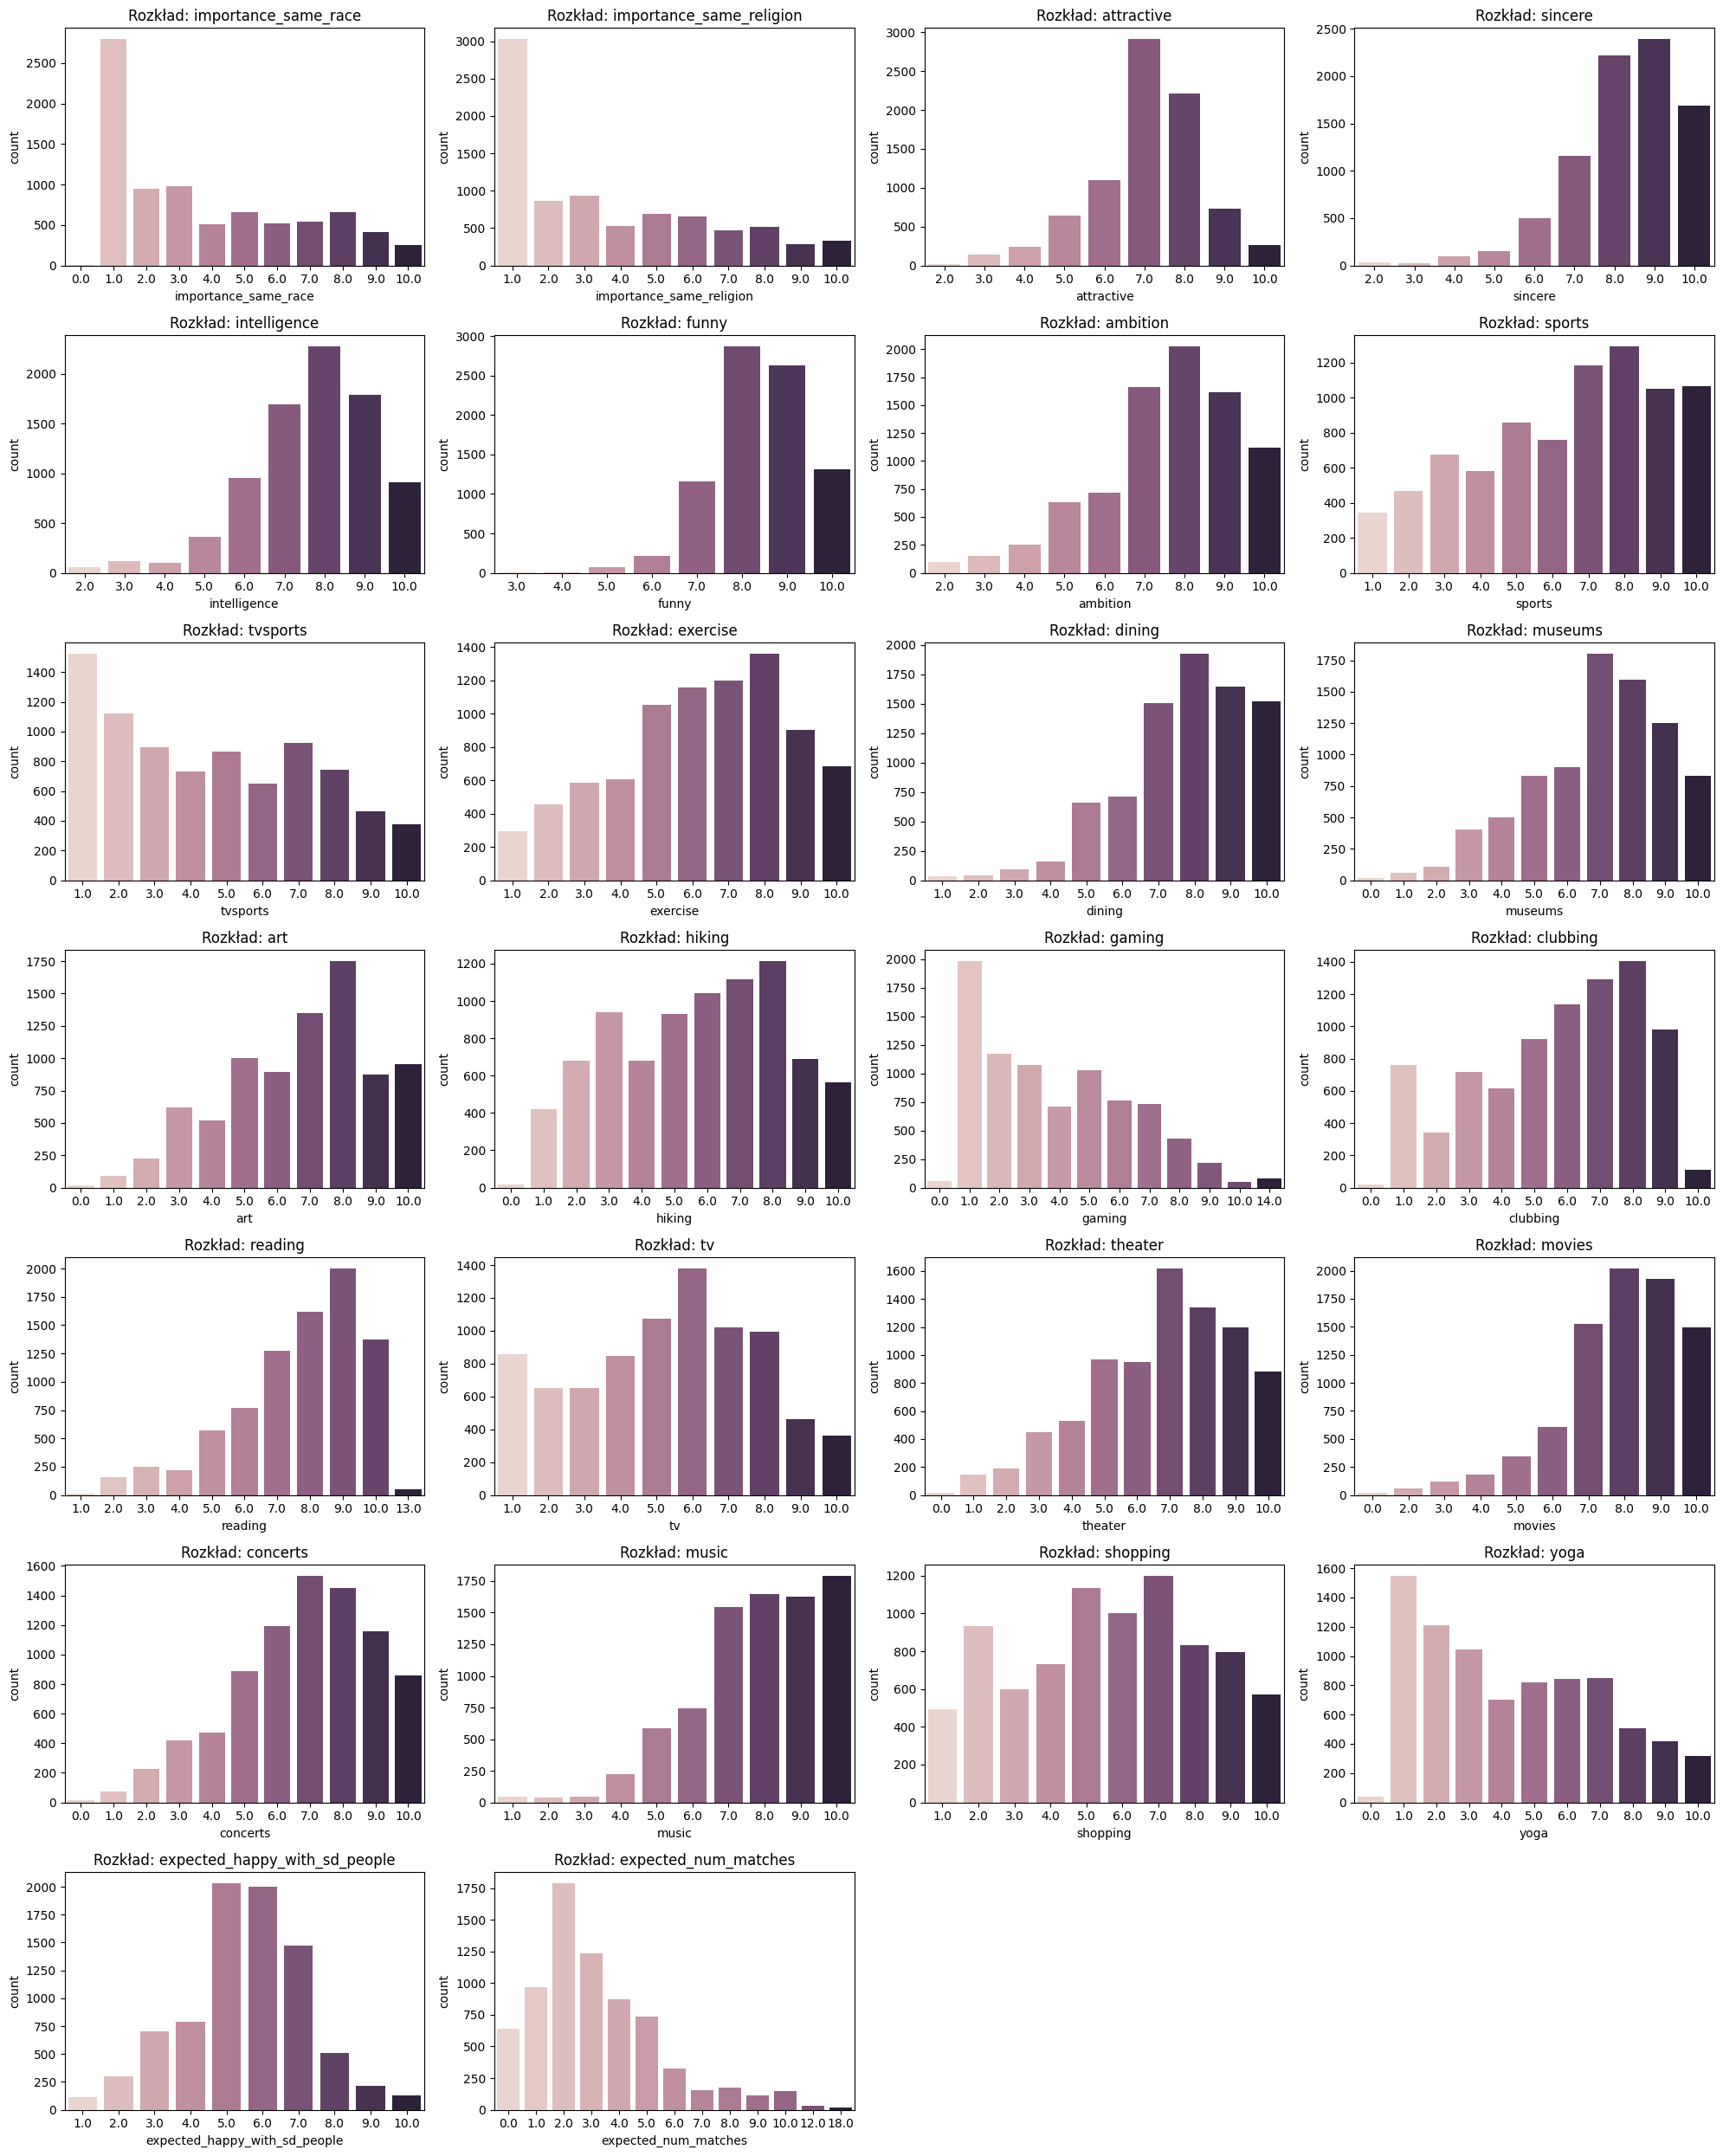

In [ ]:
discrete_cols = ['importance_same_race', 'importance_same_religion', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art',  'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater',  'movies', 'concerts', 'music', 'shopping', 'yoga', 'expected_happy_with_sd_people',  'expected_num_matches']
fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    rounded_data = df[col].round()
    
    sns.countplot(x=rounded_data, ax=axes[i], hue=rounded_data, legend=False)
    axes[i].set_title(f'Rozkład: {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

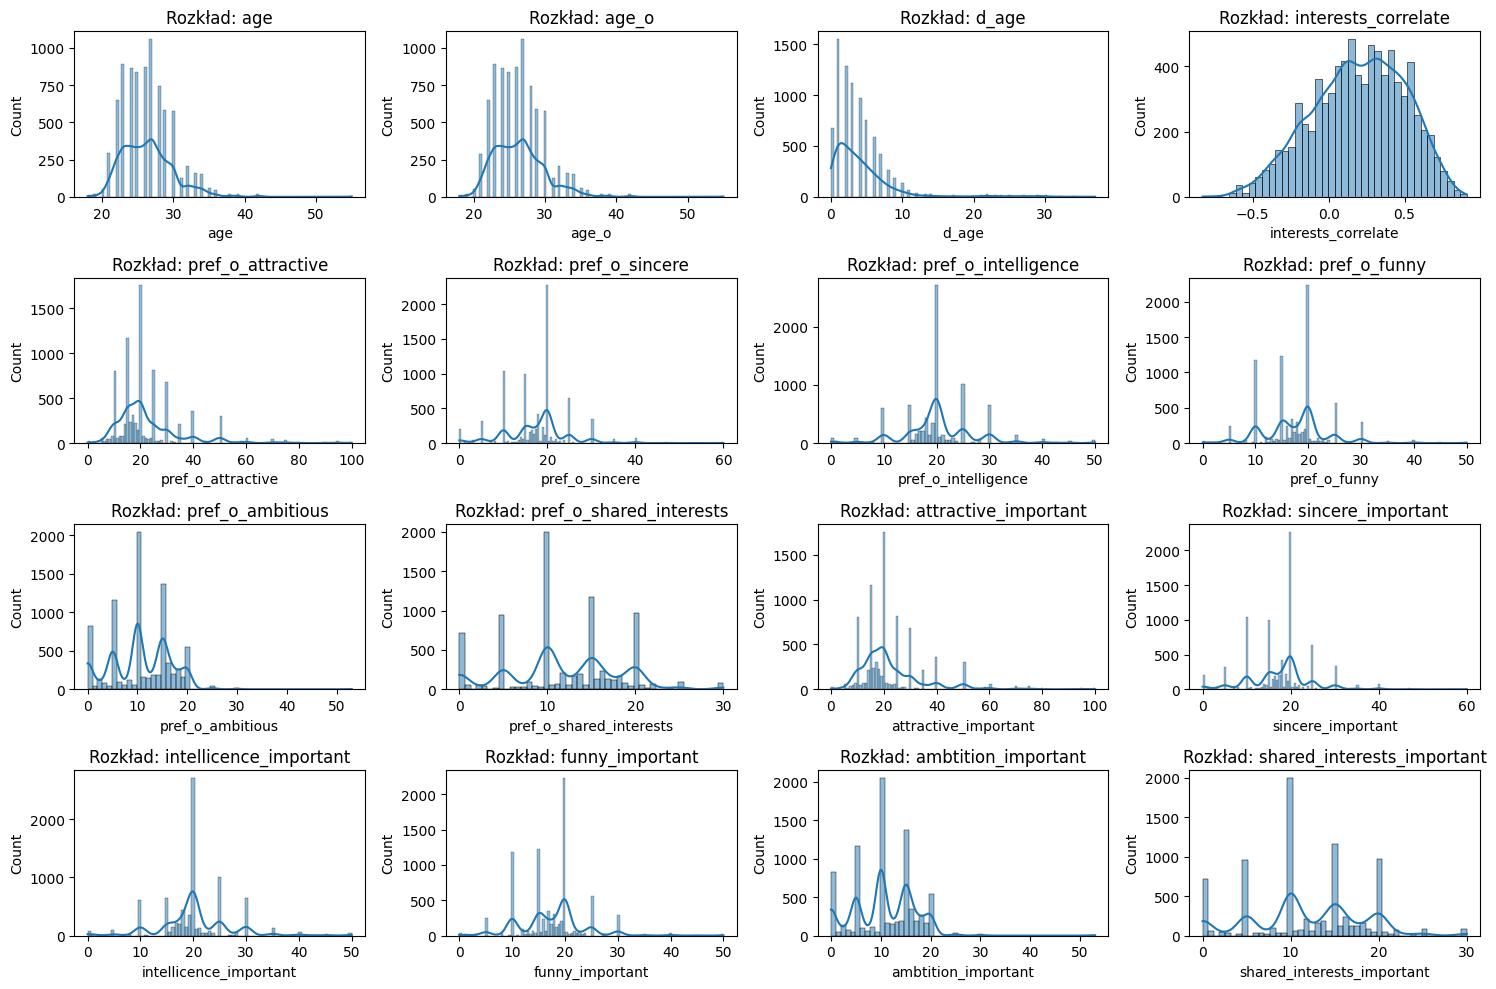

In [ ]:
continuous_cols = ['age', 'age_o', 'd_age', 'interests_correlate', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important']

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Rozkład: {col}')

plt.tight_layout()
plt.show()

In [ ]:
simple_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = simple_imputer.fit_transform(df[categorical_cols])

numerical_cols = continuous_cols + discrete_cols
knn_imputer = KNNImputer(n_neighbors=5)
df[numerical_cols] = knn_imputer.fit_transform(df[numerical_cols])

print("is nan number:\n", df.isna().sum())

is nan number:
 gender                           0
age                              0
age_o                            0
d_age                            0
race                             0
race_o                           0
samerace                         0
importance_same_race             0
importance_same_religion         0
pref_o_attractive                0
pref_o_sincere                   0
pref_o_intelligence              0
pref_o_funny                     0
pref_o_ambitious                 0
pref_o_shared_interests          0
attractive_important             0
sincere_important                0
intellicence_important           0
funny_important                  0
ambtition_important              0
shared_interests_important       0
attractive                       0
sincere                          0
intelligence                     0
funny                            0
ambition                         0
sports                           0
tvsports                         0
exer

### dodawanie nowych cech

In [68]:
df.columns

Index(['gender', 'age', 'age_o', 'd_age', 'race', 'race_o', 'samerace',
       'importance_same_race', 'importance_same_religion', 'field',
       'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence',
       'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests',
       'attractive_important', 'sincere_important', 'intellicence_important',
       'funny_important', 'ambtition_important', 'shared_interests_important',
       'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'sports',
       'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming',
       'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music',
       'shopping', 'yoga', 'interests_correlate',
       'expected_happy_with_sd_people', 'expected_num_matches', 'met', 'match',
       'id'],
      dtype='str')